# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

#### Objective

The goal is to build a predictive model capable of estimating the price of a used vehicle based on its characteristics. This model will help a car dealership better understand how different attributes influence vehicle pricing, allowing them to make more informed, data-driven decisions regarding inventory selection and pricing strategies in order to improve profitability.

The dataset contains 426,880 records, with each observation representing an individual used vehicle. It includes 18 features such as region, manufacturing year, manufacturer, model, vehicle condition, number of cylinders, fuel type, odometer reading, title status, transmission, VIN, drivetrain, vehicle size, type, paint color, and state. The variable we want to predict is the vehicle’s price, which serves as the target variable.

The model's purpose is to learn the relationship between these features and the vehicle price, helping identify which factors have the strongest impact on pricing. Model performance will be assessed using evaluation metrics such as Root Mean Square Error (RMSE) or Mean Absolute Error (MAE) to measure how accurately the model predicts used car prices.

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

>#### Initial Data Understanding

>    - Review the first few rows to familiarize yourself with the dataset layout and column names
>    - Use the info() function to examine data types and overall structure
>    - Generate summary statistics (mean, median, standard deviation, etc.) to understand numerical feature distributions
>    - Explore unique values in categorical columns to evaluate the range of categories

>#### Data Integrity Checks

>    - Identify columns with missing values and assess their magnitude
>    - Detect outliers within numerical variables
>    - Look for inconsistencies in categorical data (e.g., variations in spelling or capitalization)
>    - Check for and quantify duplicate records

>#### Exploratory Visualization

>   - Plot histograms to visualize distributions of numerical features
>    - Use bar charts to examine the frequency of categorical variables
>    - Create scatter plots to explore relationships between numerical features and the target variable (price)
>    - Build additional visualizations as needed to uncover patterns and insights

In [358]:
# import required modules
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re
import seaborn as sns

import lightgbm as lgb

from sklearn.linear_model import *
from sklearn.metrics import *
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV, HalvingRandomSearchCV, GridSearchCV, train_test_split
from sklearn.tree import *
from sklearn.ensemble import *
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from category_encoders import TargetEncoder
from ydata_profiling import ProfileReport

In [140]:
# load data from .csv file
df = pd.read_csv('data/vehicles.csv')

In [148]:
# verify data is loaded correctly
df.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [149]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

In [150]:
# check null values
df.isna().sum()

id                   0
region               0
price                0
year              1205
manufacturer     17646
model             5277
condition       174104
cylinders       177678
fuel              3013
odometer          4400
title_status      8242
transmission      2556
VIN             161042
drive           130567
size            306361
type             92858
paint_color     130203
state                0
dtype: int64

In [151]:
# Is there duplicate values
df.duplicated().sum()

np.int64(0)

In [152]:
# Display the summary statistics of the dataset
df.describe()

,id,price,year,odometer
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07


There are significant gaps between the minimum and maximum values compared to the 25th and 75th percentiles for the price, year, and odometer variables. This suggests the presence of extreme values or outliers in these columns, which may need to be addressed or removed during data cleaning.

In [153]:
# Generate a complete report over the data
#profile = ProfileReport(df)
#profile

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

In [154]:
# Rename column names to TitleCase & remove spaces & underscores
column_names = ['ID', 'Region', 'Price', 'Year', 'Manufacturer', 'Model', 'Condition', 'Cylinders', 'Fuel', 'Odometer', 'TitleStatus', 'Transmission', 'VIN', 'Drive', 'Size', 'Type', 'PaintColor', 'State']
df.columns = column_names
df.head()

,ID,Region,Price,Year,Manufacturer,Model,Condition,Cylinders,Fuel,Odometer,TitleStatus,Transmission,VIN,Drive,Size,Type,PaintColor,State
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [155]:
# Checking Price outliers
# We'll keep the 10th percentile as the minimum price and $100,000 as the maximum price
min_price = df['Price'].quantile(0.1)
max_price = 100000
df = df[(df['Price'] >= min_price) & (df['Price'] <= max_price)]

df.describe()

,ID,Price,Year,Odometer
count,3.841310e+05,384131.000000,382959.000000,3.820160e+05
mean,7.311465e+09,19161.445457,2010.972564,9.859866e+04
std,4.477699e+06,14412.286474,9.589498,1.920286e+05
min,7.207408e+09,500.000000,1900.000000,0.000000e+00
25%,7.308081e+09,7800.000000,2008.000000,3.837900e+04
50%,7.312581e+09,15900.000000,2013.000000,8.781450e+04
75%,7.315244e+09,27990.000000,2017.000000,1.360000e+05
max,7.317101e+09,100000.000000,2022.000000,1.000000e+07


In [156]:
# Odometer outliers
# We'll keep the 10th percentile as the minimum odometer reading and 500,000 as the maximum odometer reading
min_odometer = df['Odometer'].quantile(0.1)
max_odometer = 500000
df = df[(df['Odometer'] >= min_odometer) & (df['Odometer'] <= max_odometer)]

# Convert to int
df['Odometer'] = df['Odometer'].astype(int)

df.describe()

,ID,Price,Year,Odometer
count,3.426940e+05,342694.000000,342046.000000,342694.000000
mean,7.311516e+09,17824.666560,2010.747584,102501.033616
std,4.368507e+06,13409.078616,8.510210,60539.666903
min,7.301583e+09,500.000000,1900.000000,15443.000000
25%,7.308159e+09,7295.000000,2008.000000,52140.000000
50%,7.312677e+09,14500.000000,2013.000000,96854.000000
75%,7.315252e+09,25900.000000,2016.000000,141126.500000
max,7.317101e+09,100000.000000,2022.000000,500000.000000


In [157]:
# Year outliers
# We'll remove cars made prior to 1960
df = df[df['Year'] >= 1960]

# Convert to int
df['Year'] = df['Year'].astype(int)

df.describe()

,ID,Price,Year,Odometer
count,3.408990e+05,340899.000000,340899.000000,340899.000000
mean,7.311515e+09,17788.732343,2010.958413,102723.033550
std,4.368909e+06,13367.055530,7.688886,60511.427986
min,7.301583e+09,500.000000,1960.000000,15443.000000
25%,7.308158e+09,7250.000000,2008.000000,52455.500000
50%,7.312673e+09,14500.000000,2013.000000,97000.000000
75%,7.315251e+09,25795.000000,2016.000000,141514.000000
max,7.317101e+09,100000.000000,2022.000000,500000.000000


In [158]:
df.head()

,ID,Region,Price,Year,Manufacturer,Model,Condition,Cylinders,Fuel,Odometer,TitleStatus,Transmission,VIN,Drive,Size,Type,PaintColor,State
27,7316814884,auburn,33590,2014,gmc,sierra 1500 crew cab slt,good,8 cylinders,gas,57923,clean,other,3GTP1VEC4EG551563,NaN,NaN,pickup,white,al
28,7316814758,auburn,22590,2010,chevrolet,silverado 1500,good,8 cylinders,gas,71229,clean,other,1GCSCSE06AZ123805,NaN,NaN,pickup,blue,al
29,7316814989,auburn,39590,2020,chevrolet,silverado 1500 crew,good,8 cylinders,gas,19160,clean,other,3GCPWCED5LG130317,NaN,NaN,pickup,red,al
30,7316743432,auburn,30990,2017,toyota,tundra double cab sr,good,8 cylinders,gas,41124,clean,other,5TFRM5F17HX120972,NaN,NaN,pickup,red,al
31,7316356412,auburn,15000,2013,ford,f-150 xlt,excellent,6 cylinders,gas,128000,clean,automatic,NaN,rwd,full-size,truck,black,al


In [159]:
df.isnull().sum()

ID                   0
Region               0
Price                0
Year                 0
Manufacturer     11579
Model             3375
Condition       132065
Cylinders       133707
Fuel              1950
Odometer             0
TitleStatus       5764
Transmission      1337
VIN             136304
Drive           101022
Size            239157
Type             74883
PaintColor       98218
State                0
dtype: int64

In [160]:
# Removing records with price = 0
df_clean = df.query('Price > 0')

# Droping id, VIN as this is an unique value and we can't use it into regressions
# Droping region and will use state for location
df_clean = df_clean.drop(['ID', 'VIN', 'Region', 'Size', 'PaintColor', 'Drive'], axis=1)

# Fill missing values safely
df_clean["Year"] = df_clean["Year"].fillna(df_clean["Year"].mode()[0])
df_clean['Year'] = df_clean['Year'].apply(lambda x: int(x))
df_clean["Manufacturer"] = df_clean["Manufacturer"].fillna('other')
df_clean["Model"] = df_clean["Model"].fillna('other')
df_clean["Condition"] = df_clean["Condition"].fillna(df_clean["Condition"].mode()[0])
df_clean["Cylinders"] = df_clean['Cylinders'].str.replace(' cylinders', '')
df_clean["Cylinders"] = df_clean["Cylinders"].fillna(df_clean["Cylinders"].mode()[0])
df_clean["Cylinders"] = df_clean['Cylinders'].str.replace('other', df_clean["Cylinders"].mode()[0])
df_clean["Cylinders"] = pd.to_numeric(df_clean['Cylinders'])
df_clean["Fuel"] = df_clean["Fuel"].fillna('other')
df_clean["Odometer"] = df_clean["Odometer"].fillna(df_clean["Odometer"].mean())
df_clean["TitleStatus"] = df_clean["TitleStatus"].fillna(df_clean["TitleStatus"].mode()[0])
df_clean["Transmission"] = df_clean["Transmission"].fillna('other')
df_clean["Type"] = df_clean["Type"].fillna('other')

# Function used to extract the first word of the model
def first_words(item):
    model = item["Model"]
    segments = re.split(r"[, \!?:]+", model)
    index = 0
    value = segments[index]

    # If the model is compound with the manufacturer name
    if(value == item["Manufacturer"]): 
        index += 1 
        if(len(segments) > index):
            value = segments[index]   

    return value.title() 

df_clean['Model'] = df_clean['Model'].str.replace('-', '')
df_clean['Model'] = df_clean.apply(first_words, axis=1)


# Removing inaccurate records: First vehicle with automstic transmission started at 1948
df_clean = df_clean.query('not(Year < 1948 and Transmission == "automatic")')

# Drop the duplicate rows
df = df_clean.drop_duplicates()

df.sample(10)

# Rows after dropping duplicates
print("Number of Rows in the Dataset after Dropping Duplicates:", df.shape[0])

Number of Rows in the Dataset after Dropping Duplicates: 242204


In [161]:
df.head()

,Price,Year,Manufacturer,Model,Condition,Cylinders,Fuel,Odometer,TitleStatus,Transmission,Type,State
27,33590,2014,gmc,Sierra,good,8,gas,57923,clean,other,pickup,al
28,22590,2010,chevrolet,Silverado,good,8,gas,71229,clean,other,pickup,al
29,39590,2020,chevrolet,Silverado,good,8,gas,19160,clean,other,pickup,al
30,30990,2017,toyota,Tundra,good,8,gas,41124,clean,other,pickup,al
31,15000,2013,ford,F150,excellent,6,gas,128000,clean,automatic,truck,al


In [162]:
df.isnull().sum()

Price           0
Year            0
Manufacturer    0
Model           0
Condition       0
Cylinders       0
Fuel            0
Odometer        0
TitleStatus     0
Transmission    0
Type            0
State           0
dtype: int64

In [163]:
# Get categorical features
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

# Get numerical features
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Display the categorical and numerical features
print("Categorical Features:", categorical_features)
print("Numerical Features:", numerical_features)

Categorical Features: ['Manufacturer', 'Model', 'Condition', 'Fuel', 'TitleStatus', 'Transmission', 'Type', 'State']
Numerical Features: ['Price', 'Year', 'Cylinders', 'Odometer']


In [164]:
# Get the number of unique values in the categorical features
for feature in categorical_features:
    print(f"Number of Unique Values in {feature}: {df[feature].nunique()}")

Number of Unique Values in Manufacturer: 42
Number of Unique Values in Model: 3414
Number of Unique Values in Condition: 6
Number of Unique Values in Fuel: 5
Number of Unique Values in TitleStatus: 6
Number of Unique Values in Transmission: 3
Number of Unique Values in Type: 13
Number of Unique Values in State: 51


In [168]:
# Get the unique values of the categorical features
for feature in categorical_features:
    print(f"Unique Values in {feature}: {df[feature].unique()}")
    print("")

Unique Values in Manufacturer: ['gmc' 'chevrolet' 'toyota' 'ford' 'jeep' 'nissan' 'ram' 'honda' 'dodge'
 'lexus' 'jaguar' 'chrysler' 'volvo' 'audi' 'infiniti' 'lincoln'
 'alfa-romeo' 'subaru' 'other' 'acura' 'hyundai' 'mercedes-benz' 'bmw'
 'volkswagen' 'mazda' 'porsche' 'kia' 'buick' 'cadillac' 'rover' 'ferrari'
 'mini' 'pontiac' 'mitsubishi' 'fiat' 'tesla' 'mercury' 'saturn'
 'harley-davidson' 'datsun' 'land rover' 'aston-martin']

Unique Values in Model: ['Sierra' 'Silverado' 'Tundra' ... 'Fusco' 'Rx&' 'Gand']

Unique Values in Condition: ['good' 'excellent' 'fair' 'like new' 'new' 'salvage']

Unique Values in Fuel: ['gas' 'other' 'diesel' 'hybrid' 'electric']

Unique Values in TitleStatus: ['clean' 'rebuilt' 'lien' 'salvage' 'missing' 'parts only']

Unique Values in Transmission: ['other' 'automatic' 'manual']

Unique Values in Type: ['pickup' 'truck' 'other' 'SUV' 'mini-van' 'sedan' 'hatchback' 'offroad'
 'bus' 'coupe' 'convertible' 'wagon' 'van']

Unique Values in State: ['al' 'a

In [170]:
# Moving on to 'Manufacturer'

# First let's remove all rows with 'harley-davidson' in 'Manufacturer' since they don't make cars
df = df[df['Manufacturer'] != 'harley-davidson']

# Title case all manufacturer names; change 'alfa-romeo' to 'Alfa Romeo', 'aston-martin'
# to 'Aston Martin', 'bmw' to 'BMW', 'gmc' to 'GMC', 'mercedes-benz' to 'Mercedes-Benz', 'rover' to 'Land Rover'

def title_case_manufacturer(text):
    if pd.isnull(text) or text == '':
        return text
    if text == 'alfa-romeo':
        return 'Alfa Romeo'
    if text == 'aston-martin':
        return 'Aston Martin'
    if text == 'bmw':
        return 'BMW'
    if text == 'gmc':
        return 'GMC'
    if text == 'mercedes-benz':
        return 'Mercedes-Benz'
    if text == 'rover':
        return 'Land Rover'
    return text.title()

df.loc[:, 'Manufacturer'] = df['Manufacturer'].apply(title_case_manufacturer)

# Print unique values in 'Manufacturer' to verify
print(df['Manufacturer'].unique())

['Gmc' 'Chevrolet' 'Toyota' 'Ford' 'Jeep' 'Nissan' 'Ram' 'Honda' 'Dodge'
 'Lexus' 'Jaguar' 'Chrysler' 'Volvo' 'Audi' 'Infiniti' 'Lincoln'
 'Alfa Romeo' 'Subaru' 'Other' 'Acura' 'Hyundai' 'Mercedes-Benz' 'Bmw'
 'Volkswagen' 'Mazda' 'Porsche' 'Kia' 'Buick' 'Cadillac' 'Land Rover'
 'Ferrari' 'Mini' 'Pontiac' 'Mitsubishi' 'Fiat' 'Tesla' 'Mercury' 'Saturn'
 'Datsun' 'Aston Martin']


In [181]:
# Title case 'Condition', 'Cylinders', 'Fuel', 'TitleStatus', 'Transmission', 'Size', 'Type', 'PaintColor'
df['Condition'] = df['Condition'].apply(lambda x: x.title() if pd.notnull(x) else x)
df['Fuel'] = df['Fuel'].apply(lambda x: x.title() if pd.notnull(x) else x)
df['TitleStatus'] = df['TitleStatus'].apply(lambda x: x.title() if pd.notnull(x) else x)
df['Transmission'] = df['Transmission'].apply(lambda x: x.title() if pd.notnull(x) else x)
df['Type'] = df['Type'].apply(lambda x: x.title() if pd.notnull(x) else x)

# Make 'State' all caps
df['State'] = df['State'].apply(lambda x: x.upper() if pd.notnull(x) else x)

In [178]:
# Confirm changes on Categorical Features
for feature in categorical_features:
    print(f"Unique Values in {feature}: {df[feature].unique()}")
    print("")

Unique Values in Manufacturer: ['Gmc' 'Chevrolet' 'Toyota' 'Ford' 'Jeep' 'Nissan' 'Ram' 'Honda' 'Dodge'
 'Lexus' 'Jaguar' 'Chrysler' 'Volvo' 'Audi' 'Infiniti' 'Lincoln'
 'Alfa Romeo' 'Subaru' 'Other' 'Acura' 'Hyundai' 'Mercedes-Benz' 'Bmw'
 'Volkswagen' 'Mazda' 'Porsche' 'Kia' 'Buick' 'Cadillac' 'Land Rover'
 'Ferrari' 'Mini' 'Pontiac' 'Mitsubishi' 'Fiat' 'Tesla' 'Mercury' 'Saturn'
 'Datsun' 'Aston Martin']

Unique Values in Model: ['Sierra' 'Silverado' 'Tundra' ... 'Fusco' 'Rx&' 'Gand']

Unique Values in Condition: ['Good' 'Excellent' 'Fair' 'Like New' 'New' 'Salvage']

Unique Values in Fuel: ['Gas' 'Other' 'Diesel' 'Hybrid' 'Electric']

Unique Values in TitleStatus: ['Clean' 'Rebuilt' 'Lien' 'Salvage' 'Missing' 'Parts Only']

Unique Values in Transmission: ['Other' 'Automatic' 'Manual']

Unique Values in Type: ['Pickup' 'Truck' 'Other' 'Suv' 'Mini-Van' 'Sedan' 'Hatchback' 'Offroad'
 'Bus' 'Coupe' 'Convertible' 'Wagon' 'Van']

Unique Values in State: ['AL' 'AK' 'AZ' 'AR' 'CA' 'CO' 'CT

In [180]:
# Numerical Features
for feature in numerical_features:
    print(f"Unique Values in {feature}: {df[feature].unique()}")
    print("")

Unique Values in Price: [33590 22590 39590 ...  6328 19853 27294]

Unique Values in Year: [2014 2010 2020 2017 2013 2012 2016 2019 2011 1992 2018 2004 2015 2001
 2006 1968 2003 2008 2007 2005 1966 2009 1998 2002 1999 1997 1995 1978
 1970 1996 1987 2000 1991 1972 2021 1988 1994 1969 1979 1984 1986 1989
 1973 1985 1976 1977 1993 1990 1965 1982 1974 1983 1980 1971 1967 1981
 1962 1975 1964 1963 1960 2022 1961]

Unique Values in Cylinders: [ 8  6  4  5  3 10 12]

Unique Values in Odometer: [ 57923  71229  19160 ... 172511  94964  26892]



### Refined Data Visualizations

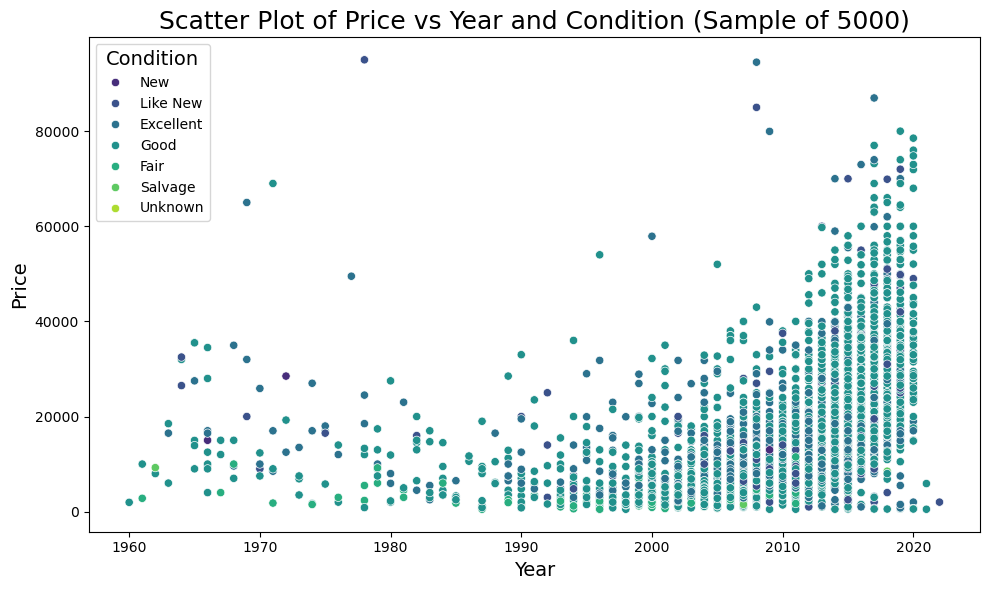

In [202]:
# Scatter plot of price vs year and condition
condition_order = ['New', 'Like New', 'Excellent', 'Good', 'Fair', 'Salvage', 'Unknown']
df_sample = df.sample(n=5000, random_state=1)
df_sample['Condition'] = pd.Categorical(df_sample['Condition'], categories=condition_order, ordered=True)

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Year', y='Price', hue='Condition', data=df_sample, palette="viridis")
plt.title('Scatter Plot of Price vs Year and Condition (Sample of 5000)', fontsize=18)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Price', fontsize=14)
plt.legend(title='Condition', title_fontsize=14)
plt.tight_layout()
plt.show()

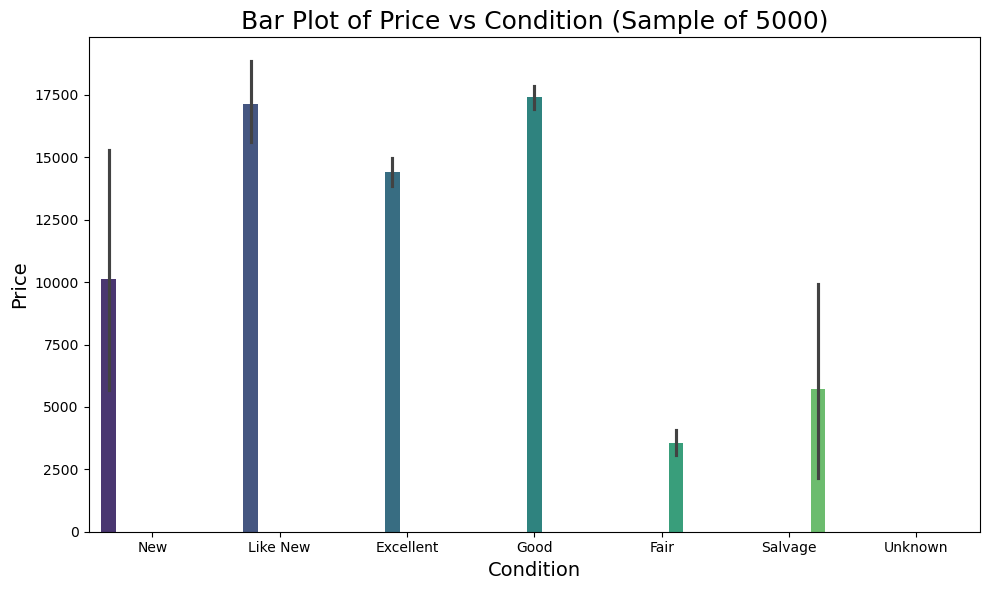

In [203]:
# Bar plot of price vs condition
condition_order = ['New', 'Like New', 'Excellent', 'Good', 'Fair', 'Salvage', 'Unknown']
df_sample = df.sample(n=5000, random_state=1)
df_sample['Condition'] = pd.Categorical(df_sample['Condition'], categories=condition_order, ordered=True)

plt.figure(figsize=(10, 6))
sns.barplot(x='Condition', y='Price', hue='Condition', data=df_sample, palette="viridis")
plt.title('Bar Plot of Price vs Condition (Sample of 5000)', fontsize=18)
plt.xlabel('Condition', fontsize=14)
plt.ylabel('Price', fontsize=14)
plt.tight_layout()
plt.show()

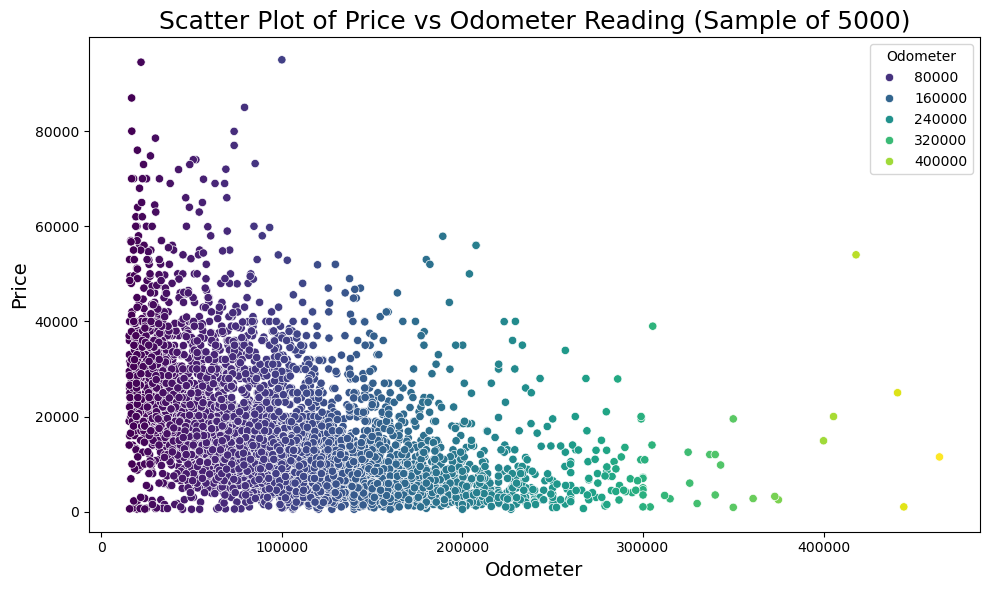

In [204]:
# Scatter plot of price vs odometer reading (5000 points)
df_sample = df.sample(n=5000, random_state=1)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Odometer', y='Price', hue='Odometer', data=df_sample, palette="viridis")
plt.title('Scatter Plot of Price vs Odometer Reading (Sample of 5000)', fontsize=18)
plt.xlabel('Odometer', fontsize=14)
plt.ylabel('Price', fontsize=14)
plt.tight_layout()
plt.show()

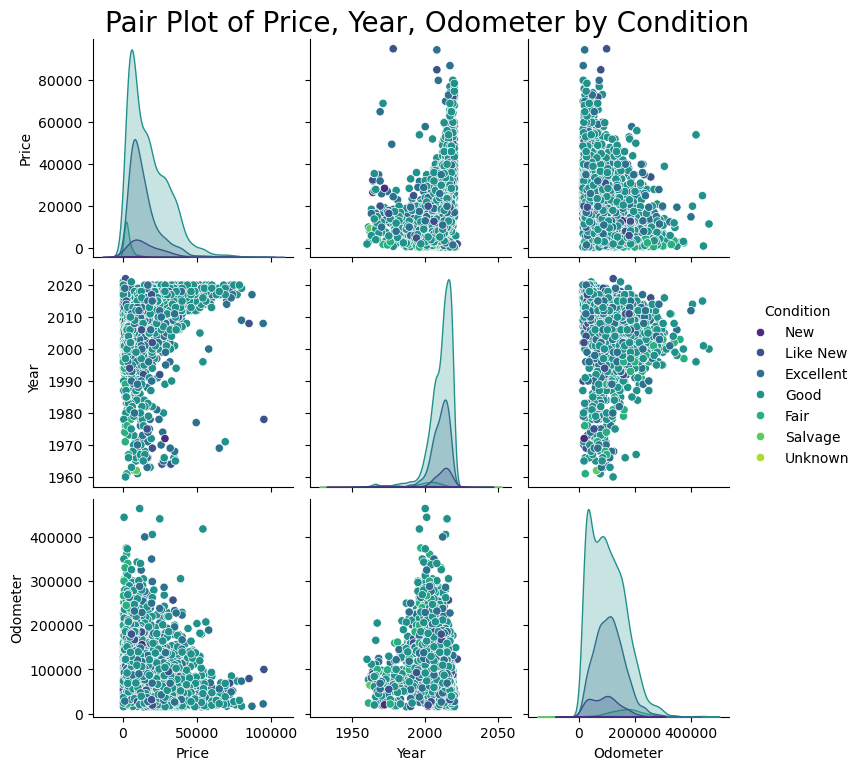

In [205]:
# Price, Year, Odometer, Condition Pair Plot
df_sample = df.sample(n=5000, random_state=1)
df_sample['Condition'] = pd.Categorical(df_sample['Condition'], categories=['New', 'Like New', 'Excellent', 'Good', 'Fair', 'Salvage', 'Unknown'], ordered=True)
sns.pairplot(df_sample, vars=['Price', 'Year', 'Odometer'], hue='Condition', palette='viridis')
plt.suptitle('Pair Plot of Price, Year, Odometer by Condition', size=20, y=1.02)
plt.show()

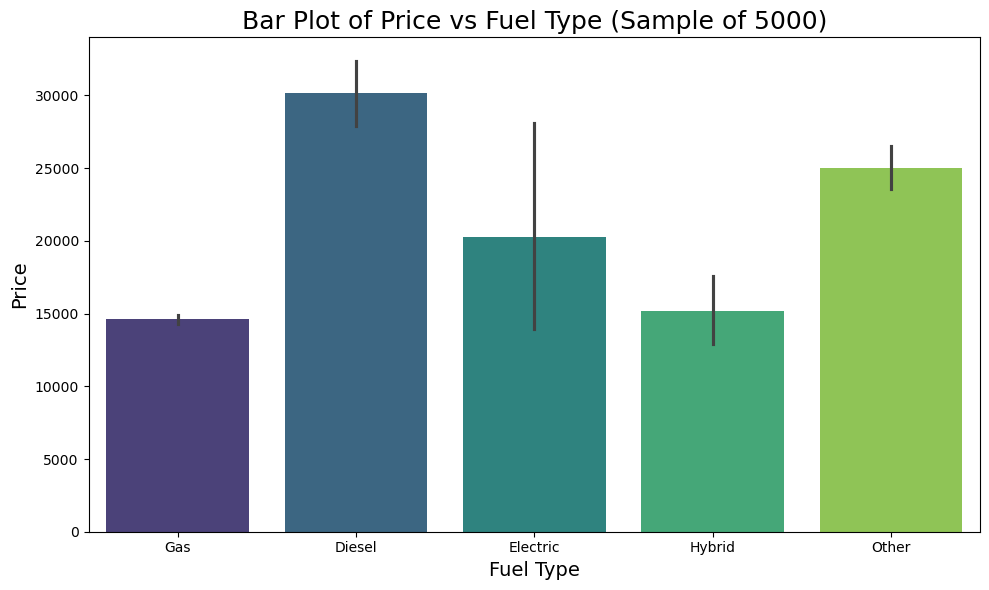

In [208]:
# Bar plot of price vs fuel type
fuel_order = ['Gas', 'Diesel', 'Electric', 'Hybrid', 'Other']
df_sample = df.sample(n=5000, random_state=1)
df_sample['Fuel'] = pd.Categorical(df_sample['Fuel'], categories=fuel_order, ordered=True)

plt.figure(figsize=(10, 6))
sns.barplot(x='Fuel', y='Price', hue='Fuel', data=df_sample, palette="viridis")
plt.title('Bar Plot of Price vs Fuel Type (Sample of 5000)', fontsize=18)
plt.xlabel('Fuel Type', fontsize=14)
plt.ylabel('Price', fontsize=14)
plt.tight_layout()
plt.show()

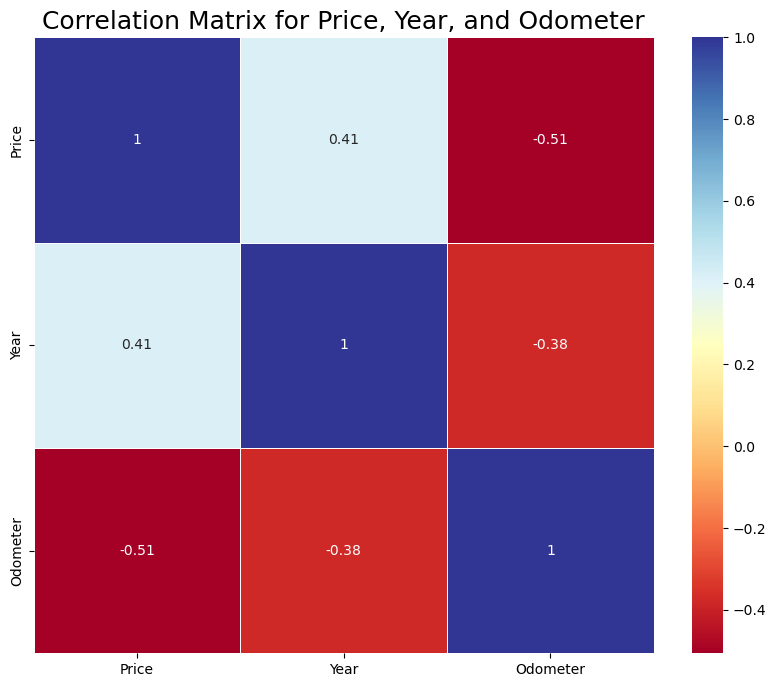

In [256]:
# Correlation matrix for numerical features
plt.figure(figsize=(10, 8))
correlation_matrix = df[['Price', 'Year', 'Odometer']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlBu', linewidths=.5)
plt.title('Correlation Matrix for Price, Year, and Odometer', fontsize=18)
plt.show()

#### Key Findings
- Vehicles in salvage condition tend to have significantly lower prices compared to all other categories
- Cars classified as fair condition are also priced noticeably lower than most other vehicles
- Vehicles in better conditions (good, excellent, like new, new) generally have higher and relatively similar average prices
- New cars show the widest price range, indicating large variability across different vehicle types
- This variation in new car prices is likely due to differences between luxury and economy models
- There is a negative relationship between odometer reading and price, meaning higher mileage typically leads to lower prices
- Cars with lower mileage tend to retain higher value in the market
- There is a positive correlation between manufacturing year and price, with newer cars being more expensive
- A negative correlation exists between year and odometer, meaning older cars usually have higher mileage
- Among fuel types, diesel vehicles are the most expensive, followed by other fuel types, electric, gas, and hybrid vehicles

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [268]:
# Instantiate the LabelEncoder
encoder = LabelEncoder()
# Perform label encoding
encoded_features = df[categorical_features].apply(encoder.fit_transform)
# Retrieve new column names from the encoder
encoded_columns = encoded_features.columns
# Create a DataFrame for the encoded features
encoded_df = pd.DataFrame(encoded_features, columns=encoded_columns)
# Concatenate encoded features with the numerical columns to form the new dataframe
numerical_data = df[numerical_features]
encoded_df = pd.concat([encoded_df, numerical_data], axis=1)
encoded_df.head()

,Manufacturer,Model,Condition,Fuel,TitleStatus,Transmission,Type,State,Price,Year,Cylinders,Odometer
27,14,2761,2,2,0,2,7,1,33590,2014,8,57923
28,7,2772,2,2,0,2,7,1,22590,2010,8,71229
29,7,2772,2,2,0,2,7,1,39590,2020,8,19160
30,37,3119,2,2,0,2,7,1,30990,2017,8,41124
31,13,1431,0,2,0,0,10,1,15000,2013,6,128000


In [276]:
# Create training and testing datasets
X = encoded_df.drop('Price', axis=1)
y = encoded_df['Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [277]:
# Scale numerical features
scaler = StandardScaler()
features_to_scale = ['Year', 'Odometer']
X_train[features_to_scale] = scaler.fit_transform(X_train[features_to_scale])
X_test[features_to_scale] = scaler.transform(X_test[features_to_scale])

In [278]:
print(f'X_train Shape: {X_train.shape}')
print(f'y_train Shape: {y_train.shape}')
print(f'X_test Shape: {X_test.shape}')
print(f'y_test Shape: {y_test.shape}')

X_train Shape: (193718, 11)
y_train Shape: (193718,)
X_test Shape: (48430, 11)
y_test Shape: (48430,)


In [279]:
# Define a function to calculate scores for each model
def calculate_scores(y_test, y_pred):
    scores = []
    scores.append(round(r2_score(y_test, y_pred), 4))
    scores.append(round(r2_score(y_test, y_pred) * 100, 4))
    scores.append(round(mean_squared_error(y_test, y_pred), 4))
    scores.append(round(np.sqrt(mean_squared_error(y_test, y_pred)), 4))
    scores.append(round(mean_absolute_error(y_test, y_pred), 4))
    return scores

# Store results in a dataframe
scores_df = pd.DataFrame(columns=['Model', 'R^2 Score', 'Accuracy (%)', 'Mean Squared Error', 'Root MSE', 'Mean Absolute Error'])

#### Linear Regression

In [281]:
######### Linear Regression #########

# Create Linear Regression model, fit and predict
linear_regression = LinearRegression()
linear_regression.fit(X_train, y_train)
best_linear_regression_model = linear_regression
y_pred_linear_regression = best_linear_regression_model.predict(X_test)

# Calculate scores for Linear Regression
scores_linear_regression = calculate_scores(y_test, y_pred_linear_regression)
linear_regression_row = {'Model': 'Linear Regression', 'R^2 Score': scores_linear_regression[0], 'Accuracy (%)': scores_linear_regression[1], 'Mean Squared Error': scores_linear_regression[2], 'Root MSE': scores_linear_regression[3], 'Mean Absolute Error': scores_linear_regression[4]}

# Ensure the new row matches the existing DataFrame columns
new_row_df = pd.DataFrame([linear_regression_row], columns=scores_df.columns)
# Fill any missing columns with NaN if needed
new_row_df = new_row_df.reindex(columns=scores_df.columns, fill_value=pd.NA)
# Concatenate safely
scores_df = pd.concat([scores_df, new_row_df], ignore_index=True)

# Display scores for Linear Regression
print("Linear Regression Scores:")
print("R^2 Score:", scores_linear_regression[0])
print("Accuracy (%):", scores_linear_regression[1])
print("Mean Squared Error:", scores_linear_regression[2])
print("Root MSE:", scores_linear_regression[3])
print("Mean Absolute Error:", scores_linear_regression[4])

Linear Regression Scores:
R^2 Score: 0.461
Accuracy (%): 46.0959
Mean Squared Error: 89726084.0306
Root MSE: 9472.3853
Mean Absolute Error: 6744.2586


#### Lasso Regression

In [283]:
######### Lasso Regression #########
# Create Lasso Regression model, fit and predict

# Define the range of alphas to test
alphas_lasso = np.logspace(-6, 1, 100)  # Testing 100 alphas from 10^-6 to 10^1

# Instantiate LassoCV
lasso_cv = LassoCV(alphas=alphas_lasso, cv=5, random_state=42)

# Fit the LassoCV to the training data
lasso_cv.fit(X_train, y_train)

# Determine the best alpha
print("Best Alpha Using Built-in LassoCV: %f" % lasso_cv.alpha_)

# Predict on the testing set
best_lasso_regression_model = lasso_cv
y_pred_lasso_regression = best_lasso_regression_model.predict(X_test)

# Calculate scores for Lasso Regression
scores_lasso_regression = calculate_scores(y_test, y_pred_lasso_regression)
lasso_regression_row = {'Model': 'Lasso Regression', 'R^2 Score': scores_lasso_regression[0], 'Accuracy (%)': scores_lasso_regression[1], 'Mean Squared Error': scores_lasso_regression[2], 'Root MSE': scores_lasso_regression[3], 'Mean Absolute Error': scores_lasso_regression[4]}
scores_df = pd.concat([scores_df, pd.DataFrame([lasso_regression_row])], ignore_index=True)

# Display scores for Lasso Regression
print("Lasso Regression Scores:")
print("R^2 Score:", scores_lasso_regression[0])
print("Accuracy (%):", scores_lasso_regression[1])
print("Mean Squared Error:", scores_lasso_regression[2])
print("Root MSE:", scores_lasso_regression[3])
print("Mean Absolute Error:", scores_lasso_regression[4])

Best Alpha Using Built-in LassoCV: 0.000001
Lasso Regression Scores:
R^2 Score: 0.461
Accuracy (%): 46.0959
Mean Squared Error: 89726084.0303
Root MSE: 9472.3853
Mean Absolute Error: 6744.2586


#### Ridge Regression

In [284]:
######### Ridge Regression #########

# Create Ridge Regression model, fit and predict

from sklearn.linear_model import RidgeCV

# Define alphas
alphas_ridge = np.logspace(-6, 6, 13)  # 10^-6 to 10^6

# Correct RidgeCV usage
ridge_cv = RidgeCV(alphas=alphas_ridge, store_cv_results=False, cv=5)  # Use cv for cross-validation

# Fit the model
ridge_cv.fit(X_train, y_train)

# Predictions
y_pred_train_ridge = ridge_cv.predict(X_train)
y_pred_test_ridge = ridge_cv.predict(X_test)

# Evaluate
from sklearn.metrics import mean_squared_error
import numpy as np

print(f"Best alpha: {ridge_cv.alpha_}")
print(f"Training RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train_ridge))}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test_ridge))}")

# Predict with the best model
best_ridge_regression_model = ridge_cv
y_pred_ridge_regression = best_ridge_regression_model.predict(X_test)

# Calculate scores for Ridge Regression
scores_ridge_regression = calculate_scores(y_test, y_pred_ridge_regression)
ridge_regression_row = {'Model': 'Ridge Regression', 'R^2 Score': scores_ridge_regression[0], 'Accuracy (%)': scores_ridge_regression[1], 'Mean Squared Error': scores_ridge_regression[2], 'Root MSE': scores_ridge_regression[3], 'Mean Absolute Error': scores_ridge_regression[4]}
scores_df = pd.concat([scores_df, pd.DataFrame([ridge_regression_row])], ignore_index=True)

# Display scores for Ridge Regression
print("Ridge Regression Scores:")
print("R^2 Score:", scores_ridge_regression[0])
print("Accuracy (%):", scores_ridge_regression[1])
print("Mean Squared Error:", scores_ridge_regression[2])
print("Root MSE:", scores_ridge_regression[3])
print("Mean Absolute Error:", scores_ridge_regression[4])

Best alpha: 10.0
Training RMSE: 9516.06247695757
Test RMSE: 9472.381632749437
Ridge Regression Scores:
R^2 Score: 0.461
Accuracy (%): 46.0959
Mean Squared Error: 89726013.7964
Root MSE: 9472.3816
Mean Absolute Error: 6744.2459


#### Random Forest

In [285]:
######### Random Forest  #########
# Create Random Forest (Base) model, fit and predict
random_forest_base = RandomForestRegressor(n_estimators=50, random_state=42)
random_forest_base.fit(X_train, y_train)
best_random_forest_base_model = random_forest_base
y_pred_random_forest_base = best_random_forest_base_model.predict(X_test)

# Calculate scores for Random Forest (Base)
scores_random_forest_base = calculate_scores(y_test, y_pred_random_forest_base)
random_forest_base_row = {'Model': 'Random Forest (Base)', 'R^2 Score': scores_random_forest_base[0], 'Accuracy (%)': scores_random_forest_base[1], 'Mean Squared Error': scores_random_forest_base[2], 'Root MSE': scores_random_forest_base[3], 'Mean Absolute Error': scores_random_forest_base[4]}
scores_df = pd.concat([scores_df, pd.DataFrame([random_forest_base_row])], ignore_index=True)

# Display scores for Random Forest (Base)
print("Random Forest (Base) Scores:")
print("R^2 Score:", scores_random_forest_base[0])
print("Accuracy (%):", scores_random_forest_base[1])
print("Mean Squared Error:", scores_random_forest_base[2])
print("Root MSE:", scores_random_forest_base[3])
print("Mean Absolute Error:", scores_random_forest_base[4])

Random Forest (Base) Scores:
R^2 Score: 0.8446
Accuracy (%): 84.4615
Mean Squared Error: 25864699.611
Root MSE: 5085.7349
Mean Absolute Error: 2745.245


In [ ]:

import multiprocessing as mp

if __name__ == "__main__":
    mp.set_start_method("spawn", force=True)
    
# Create Random Forest (Optimized) model, fit and predict
random_forest_optimized = RandomForestRegressor(random_state=42)

# Define a parameter grid to search for best parameters
parameter_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30]
}

# Use GridSearchCV to search for best parameters
grid_search = GridSearchCV(estimator=random_forest_optimized, param_grid=parameter_grid, cv=3, n_jobs=-1, verbose=2, scoring='neg_mean_squared_error')

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Best parameters and best score
print("Best Parameters:", grid_search.best_params_)
print("Best Score (MSE):", -grid_search.best_score_)

Fitting 3 folds for each of 9 candidates, totalling 27 fits


In [287]:
# Use the best estimator to make predictions
best_random_forest_optimized_model = grid_search.best_estimator_
y_pred_random_forest_optimized = best_random_forest_optimized_model.predict(X_test)

# Calculate scores for Random Forest (Optimized)
scores_random_forest_optimized = calculate_scores(y_test, y_pred_random_forest_optimized)
random_forest_optimized_row = {'Model': 'Random Forest (Optimized)', 'R^2 Score': scores_random_forest_optimized[0], 'Accuracy (%)': scores_random_forest_optimized[1], 'Mean Squared Error': scores_random_forest_optimized[2], 'Root MSE': scores_random_forest_optimized[3], 'Mean Absolute Error': scores_random_forest_optimized[4]}
scores_df = pd.concat([scores_df, pd.DataFrame([random_forest_optimized_row])], ignore_index=True)

# Display scores for Random Forest (Optimized)
print("Random Forest (Optimized) Scores:")
print("R^2 Score:", scores_random_forest_optimized[0])
print("Accuracy (%):", scores_random_forest_optimized[1])
print("Mean Squared Error:", scores_random_forest_optimized[2])
print("Root MSE:", scores_random_forest_optimized[3])
print("Mean Absolute Error:", scores_random_forest_optimized[4])

Random Forest (Optimized) Scores:
R^2 Score: 0.8472
Accuracy (%): 84.7179
Mean Squared Error: 25437822.098
Root MSE: 5043.5922
Mean Absolute Error: 2714.9115


### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

In [338]:
######### Summary of Models' Performance #########
# Remove duplicates
unique_scores = scores_df.drop_duplicates(subset=['Model', 'Accuracy (%)']).reset_index(drop=True)
unique_scores

,Model,R^2 Score,Accuracy (%),Mean Squared Error,Root MSE,Mean Absolute Error
0,Linear Regression,0.4610,46.0959,8.972608e+07,9472.3853,6744.2586
1,Lasso Regression,0.4610,46.0959,8.972608e+07,9472.3853,6744.2586
2,Ridge Regression,0.4610,46.0959,8.972601e+07,9472.3816,6744.2459
3,Random Forest (Base),0.8446,84.4615,2.586470e+07,5085.7349,2745.2450
4,Random Forest (Optimized),0.8472,84.7179,2.543782e+07,5043.5922,2714.9115


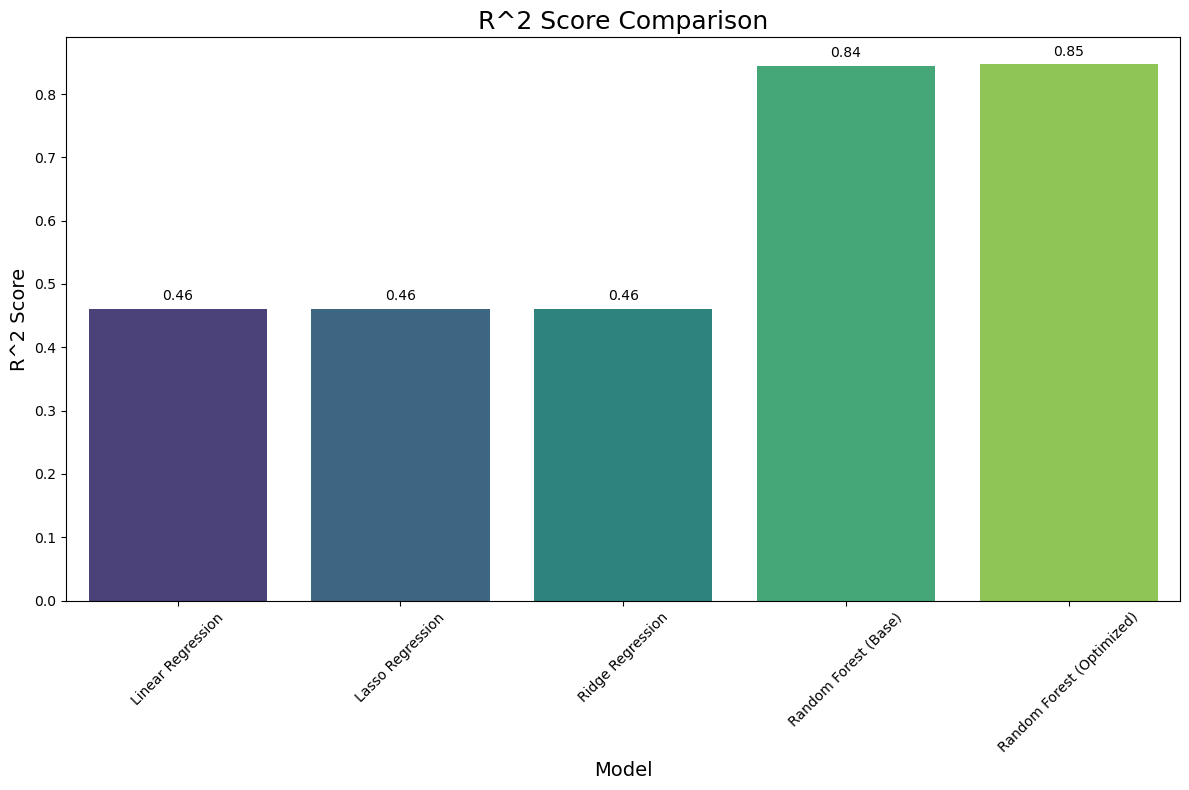

In [339]:
######### Visual Score Comparisons #########
# R^2 Score Comparison
plt.figure(figsize=(12, 8))
barplot = sns.barplot(x='Model', y='R^2 Score', hue='Model', data=unique_scores, palette="viridis")
plt.title('R^2 Score Comparison', fontsize=18)
plt.xlabel('Model', fontsize=14)
plt.ylabel('R^2 Score', fontsize=14)
plt.xticks(rotation=45)
for p in barplot.patches:
    barplot.annotate(format(p.get_height(), '.2f'), (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 9), textcoords='offset points')
plt.tight_layout()
plt.show()

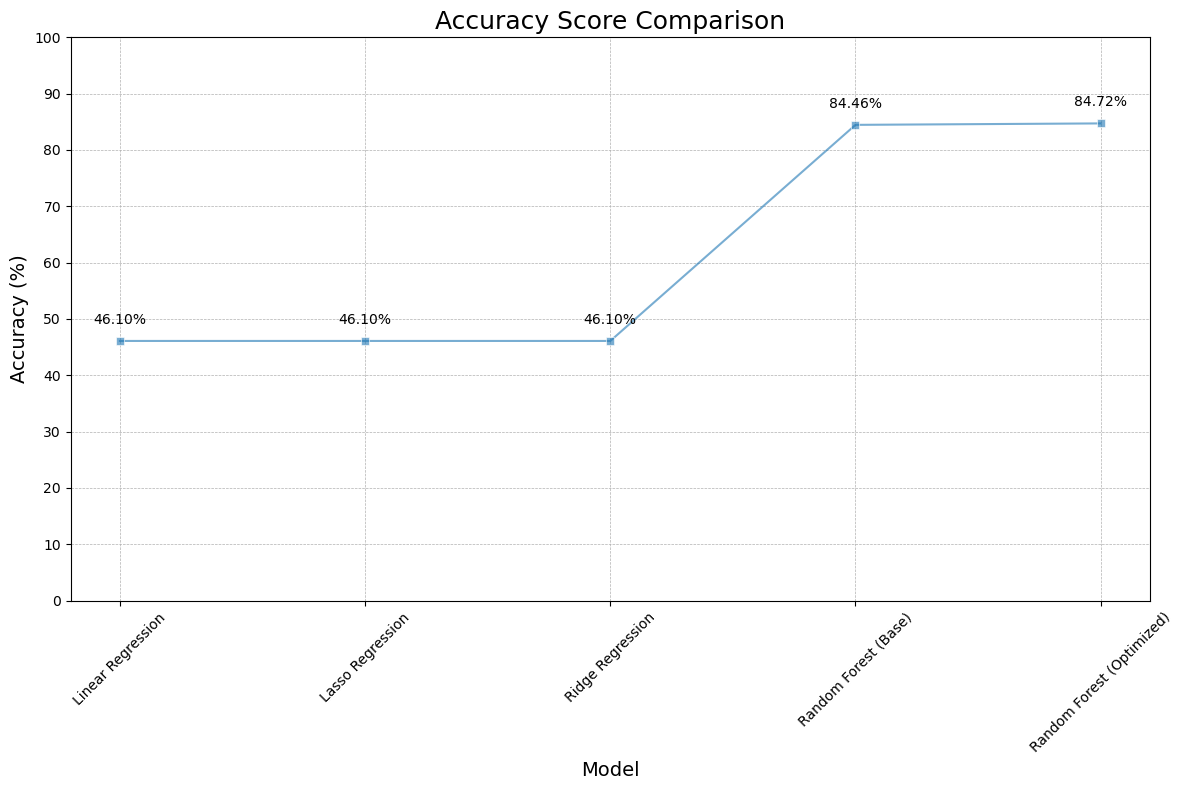

In [341]:
# Accuracy Score Comparison


plt.figure(figsize=(12, 8))
line = sns.lineplot(x='Model', y='Accuracy (%)', data=unique_scores, marker="s", alpha=0.6)

plt.title('Accuracy Score Comparison', fontsize=18)
plt.xlabel('Model', fontsize=14)
plt.ylabel('Accuracy (%)', fontsize=14)
# Extend y-axis slightly above 100 to accommodate labels
plt.yticks(np.arange(0, 101, 10))
plt.xticks(rotation=45)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
for x, y in zip(range(len(unique_scores['Model'])), unique_scores['Accuracy (%)']):
    plt.text(x, y + 2.5, f'{y:.2f}%', ha='center', va='bottom')
plt.tight_layout()
plt.show()

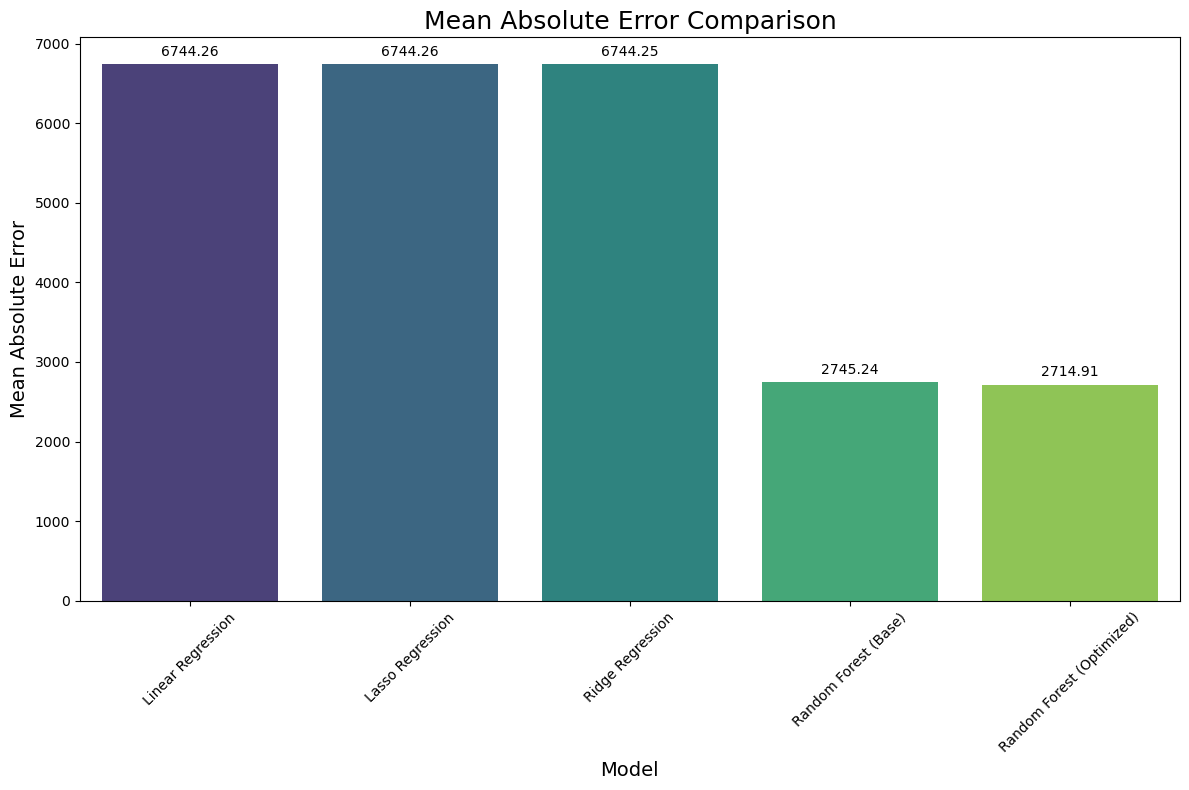

In [344]:
# Mean Absolute Error Comparison
plt.figure(figsize=(12, 8))
barplot = sns.barplot(x='Model', y='Mean Absolute Error', hue='Model', data=unique_scores, palette="viridis")
plt.title('Mean Absolute Error Comparison', fontsize=18)
plt.xlabel('Model', fontsize=14)
plt.ylabel('Mean Absolute Error', fontsize=14)
plt.xticks(rotation=45)
for p in barplot.patches:
    barplot.annotate(format(p.get_height(), '.2f'), (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 9), textcoords='offset points')
plt.tight_layout()
plt.show()

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

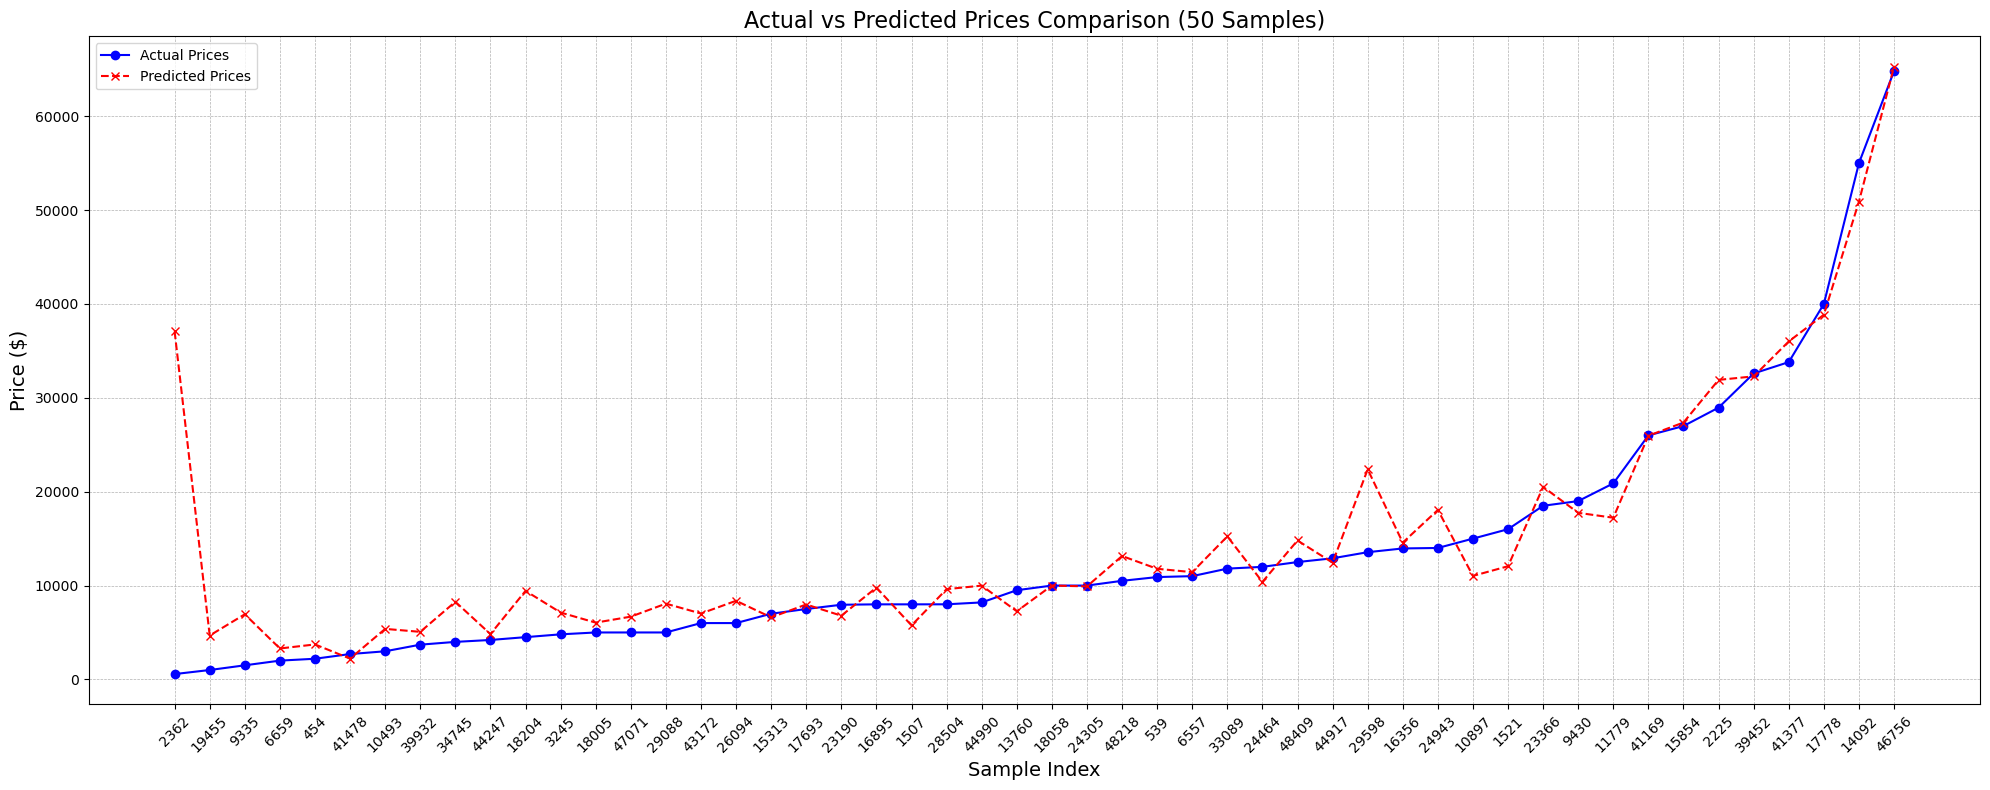

In [345]:
######### Testing Best Model on Sample Data #########

# Plot of actual vs predicted prices for the Random Forest (Optimized) model (50 samples)

# Selecting 50 random samples for plotting
samples_index = np.random.choice(len(y_pred_random_forest_optimized), 50, replace=False)
actual_samples = y_test.iloc[samples_index]
predicted_samples = y_pred_random_forest_optimized[samples_index]

# Sorting the samples by actual prices
sorted_indices = actual_samples.argsort()
sorted_actual_samples = actual_samples.values[sorted_indices]
sorted_predicted_samples = predicted_samples[sorted_indices]

# Plotting both actual and predicted prices
plt.figure(figsize=(20, 8))
plt.plot(sorted_actual_samples, label='Actual Prices', color='blue', marker='o')
plt.plot(sorted_predicted_samples, label='Predicted Prices', color='red', linestyle='--', marker='x')
plt.title('Actual vs Predicted Prices Comparison (50 Samples)', fontsize=16)
plt.xlabel('Sample Index', fontsize=14)
plt.ylabel('Price ($)', fontsize=14)
plt.xticks(range(50), labels=[str(samples_index[i]) for i in sorted_indices], rotation=45)
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

In [347]:
######### Feature Importances #########

# Calculate feature importances
features = []
importances = []
for name, importance in zip(X, best_random_forest_optimized_model.feature_importances_):
    features.append(name)
    importances.append(round(importance * 100, 2))

features = pd.DataFrame({'Features': features, 'Importance (%)': importances})
features.sort_values(by='Importance (%)', ascending=False)

,Features,Importance (%)
8,Year,40.45
10,Odometer,14.07
1,Model,10.66
3,Fuel,10.10
9,Cylinders,9.05
0,Manufacturer,6.34
6,Type,3.21
7,State,3.06
2,Condition,1.37
5,Transmission,1.06


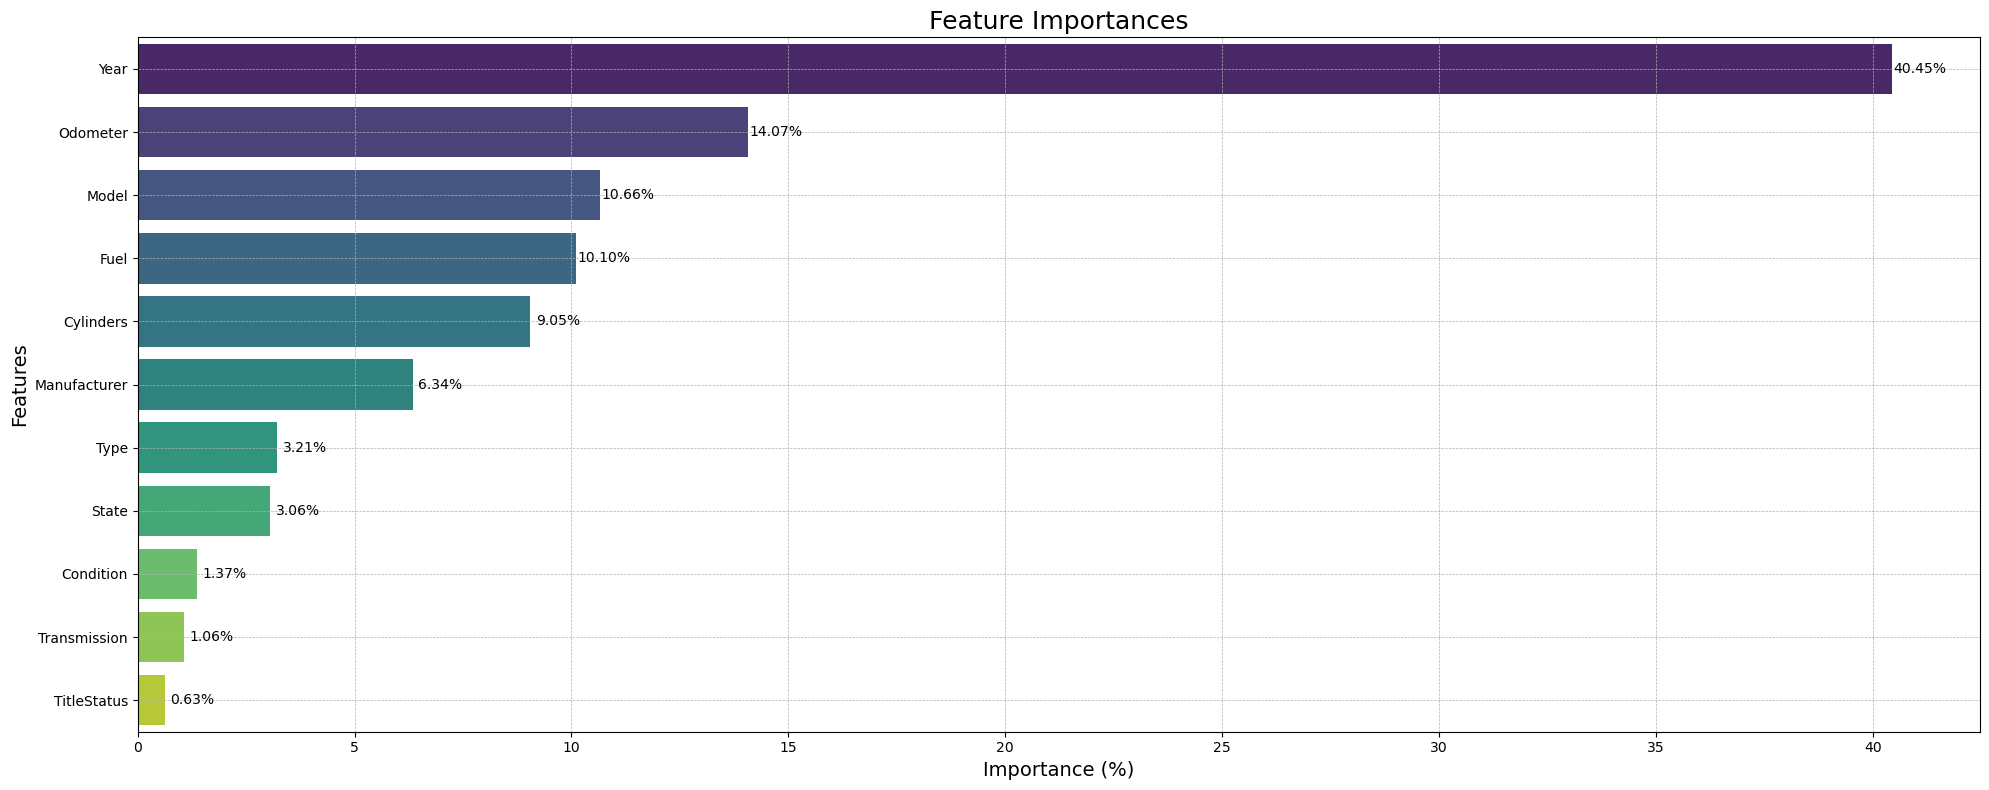

In [356]:
# Plot feature importances
plt.figure(figsize=(20, 8))
# Sorting the features dataframe by 'Importance (%)' in descending order before plotting
features_sorted = features.sort_values(by='Importance (%)', ascending=False)
barplot = sns.barplot(x='Importance (%)', y='Features', hue='Features', data=features_sorted, palette="viridis")
plt.title('Feature Importances', fontsize=18)
plt.xlabel('Importance (%)', fontsize=14)
plt.ylabel('Features', fontsize=14)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
for p in barplot.patches:
    barplot.annotate(f"{format(p.get_width(), '.2f')}%", (p.get_width() + 0.35, p.get_y() + p.get_height() / 2.), ha='center', va='center', xytext=(9, 0), textcoords='offset points')
plt.tight_layout()
plt.show()

In [362]:
encoded_df.head()

,Manufacturer,Model,Condition,Fuel,TitleStatus,Transmission,Type,State,Price,Year,Cylinders,Odometer
27,14,2761,2,2,0,2,7,1,33590,2014,8,57923
28,7,2772,2,2,0,2,7,1,22590,2010,8,71229
29,7,2772,2,2,0,2,7,1,39590,2020,8,19160
30,37,3119,2,2,0,2,7,1,30990,2017,8,41124
31,13,1431,0,2,0,0,10,1,15000,2013,6,128000


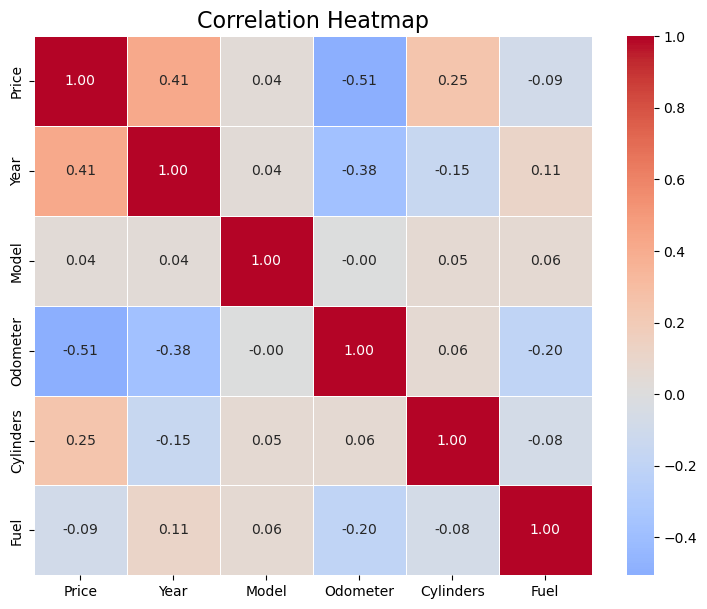

In [368]:
######### Correlation using feature importance #########
# Plot correlation heatmap
# Select the top features (ensure they are numeric)
features_importance = ["Price", "Year", "Model", "Odometer", "Cylinders", "Fuel"]  # Keep only numeric for correlation

# Subset the dataframe
df_top_features = encoded_df[features_importance]

plt.figure(figsize=(9, 7))
sns.heatmap(df_top_features.corr(), 
            center=0, 
            linewidth=0.7, 
            annot=True, 
            fmt=".2f", 
            cmap="coolwarm")
plt.title('Correlation Heatmap', fontsize=16)
plt.show()